<a href="https://colab.research.google.com/github/PratipravaDawn/AI-Based-Road-Condition-Monitoring-System/blob/main/PotholeDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
def extract_features(df, label, window_size=10):
    """Converts raw sensor rows into statistical windows(small invervals of time)"""
    features = []
    step = window_size // 2 # 50% overlap to get more training data
    for i in range(0, len(df) - window_size, step):
        window = df.iloc[i : i + window_size]
        features.append({
            'accZ_std': window['accelerometerZ'].std(), #standard deviation
            'accZ_p2p': window['accelerometerZ'].max() - window['accelerometerZ'].min(), #peak to peak
            'accX_std': window['accelerometerX'].std(),
            'accY_std': window['accelerometerY'].std(),
            'label': label
        })
    return features

In [ ]:
all_feature_lists = []

In [ ]:
# 1. Process Good Roads (Label 0)
for f in range(1,11):
    df = pd.read_csv(f"/content/drive/MyDrive/Project Pothole/pothole datasets/RoadCondition/good/good10_sensors.csv")
    all_feature_lists.extend(extract_features(df, 0))

In [ ]:
# 2. Process Bad Roads (Label 1)
for f in range(1,6):
    df = pd.read_csv(f"/content/drive/MyDrive/Project Pothole/pothole datasets/RoadCondition/bad/bad{f}_sensors.csv")
    all_feature_lists.extend(extract_features(df, 1))

In [ ]:
# 3. Process Potholes from Trips (Label 2)
for f in range(1,6):
    sensors = pd.read_csv(f"/content/drive/MyDrive/Project Pothole/pothole datasets/Pothole/trip{f}_sensors.csv")
    potholes = pd.read_csv(f"/content/drive/MyDrive/Project Pothole/pothole datasets/Pothole/trip{f}_potholes.csv")

In [ ]:
for ts in potholes['timestamp']:
        idx = (sensors['timestamp'] - ts).abs().idxmin()
        window = sensors.iloc[max(0, idx-5) : min(len(sensors), idx+5)]
        if len(window) == 10:
            all_feature_lists.append({
                'accZ_std': window['accelerometerZ'].std(),
                'accZ_p2p': window['accelerometerZ'].max() - window['accelerometerZ'].min(),
                'accX_std': window['accelerometerX'].std(),
                'accY_std': window['accelerometerY'].std(),
                'label': 2
            })

In [ ]:
# Final Merged Dataset
final_df = pd.DataFrame(all_feature_lists)
print(f"Total Windows for Training: {len(final_df)}")
print(final_df['label'].value_counts())

Total Windows for Training: 1030
label
0    600
1    412
2     18
Name: count, dtype: int64


In [ ]:
final_df

,accZ_std,accZ_p2p,accX_std,accY_std,label
0,0.076377,0.188736,0.028433,0.021293,0
1,0.044848,0.133377,0.044230,0.024052,0
2,0.043449,0.137115,0.052825,0.032366,0
3,0.057105,0.149384,0.055859,0.056774,0
4,0.040300,0.114746,0.053519,0.069695,0
...,...,...,...,...,...
1025,0.082855,0.280670,0.185366,0.147217,2
1026,0.137258,0.524246,0.203285,0.147890,2
1027,0.096418,0.367493,0.338861,0.173350,2
1028,0.156468,0.548737,0.290296,0.239679,2


In [ ]:
import matplotlib.pyplot as plt

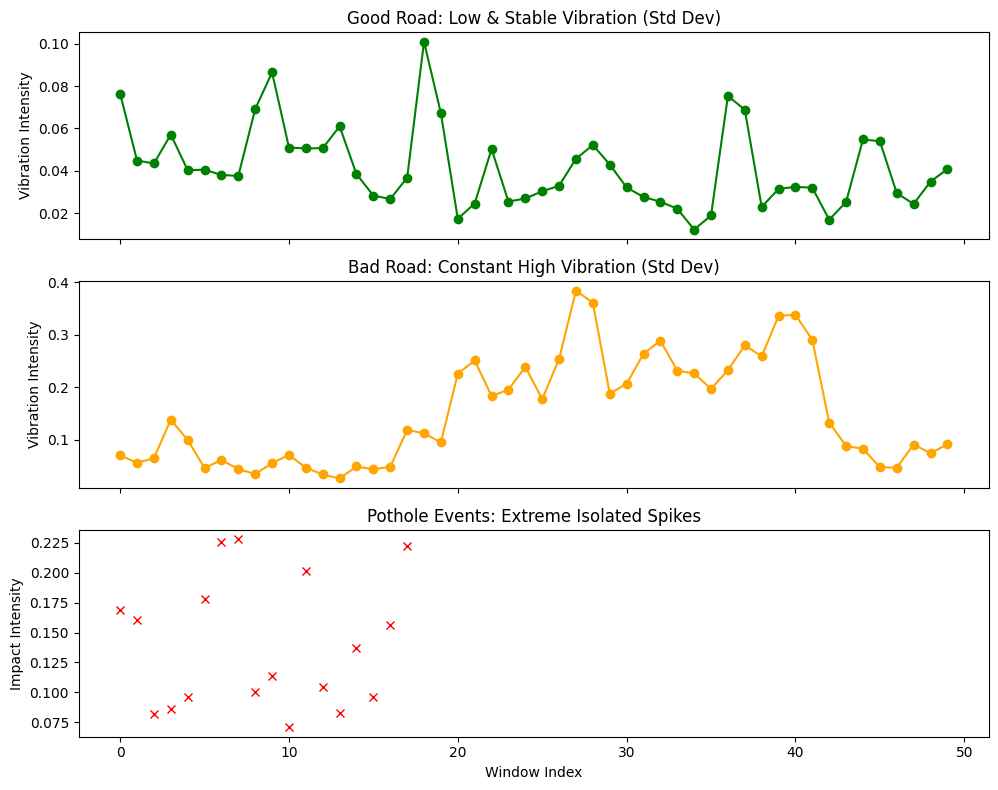

In [ ]:
# Create a comparison plot using the processed features
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# 1. Good Road (Label 0)
# We take the first 50 windows of 'Good' data
good_data = final_df[final_df['label'] == 0]['accZ_std'].iloc[:50]
axes[0].plot(good_data.values, color='green', marker='o', linestyle='-')
axes[0].set_title('Good Road: Low & Stable Vibration (Std Dev)')
axes[0].set_ylabel('Vibration Intensity')

# 2. Bad Road (Label 1)
# We take the first 50 windows of 'Bad' data
bad_data = final_df[final_df['label'] == 1]['accZ_std'].iloc[:50]
axes[1].plot(bad_data.values, color='orange', marker='o', linestyle='-')
axes[1].set_title('Bad Road: Constant High Vibration (Std Dev)')
axes[1].set_ylabel('Vibration Intensity')

# 3. Pothole (Label 2)
# We plot all detected pothole windows
pothole_data = final_df[final_df['label'] == 2]['accZ_std']
axes[2].plot(pothole_data.values, color='red', marker='x', linestyle='None')
axes[2].set_title('Pothole Events: Extreme Isolated Spikes')
axes[2].set_ylabel('Impact Intensity')
axes[2].set_xlabel('Window Index')

plt.tight_layout()
plt.show()

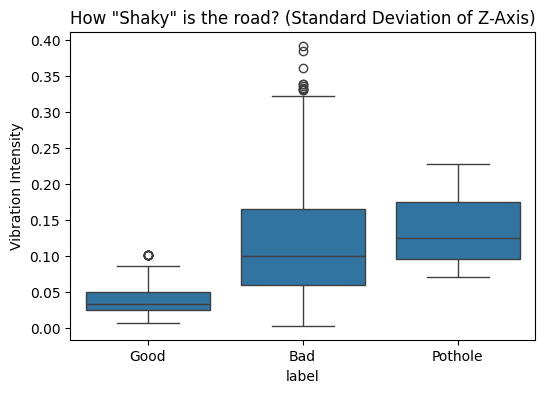

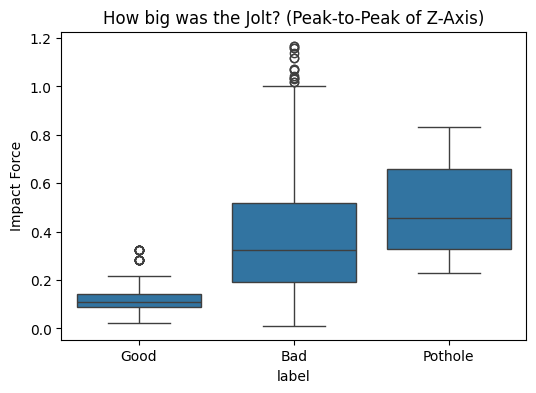

In [ ]:
import seaborn as sns

# Assuming you have created 'df_final' from the previous steps
plt.figure(figsize=(6, 4))
sns.boxplot(x='label', y='accZ_std', data=final_df)
plt.xticks([0, 1, 2], ['Good', 'Bad', 'Pothole'])
plt.title('How "Shaky" is the road? (Standard Deviation of Z-Axis)')
plt.ylabel('Vibration Intensity')
plt.show()

plt.figure(figsize=(6, 4))
sns.boxplot(x='label', y='accZ_p2p', data=final_df)
plt.xticks([0, 1, 2], ['Good', 'Bad', 'Pothole'])
plt.title('How big was the Jolt? (Peak-to-Peak of Z-Axis)')
plt.ylabel('Impact Force')
plt.show()

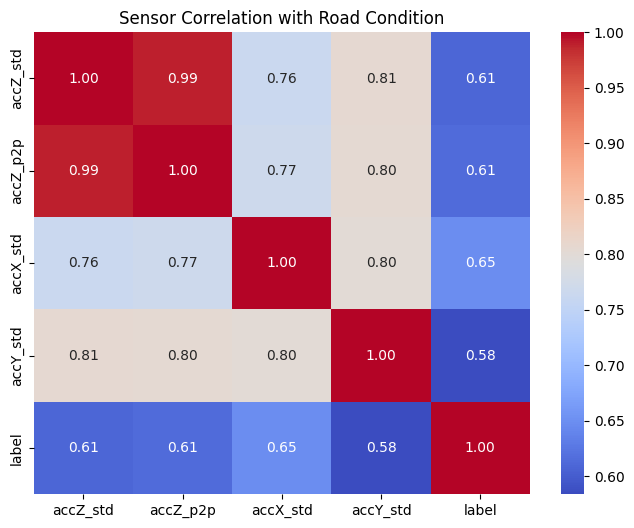

In [ ]:
plt.figure(figsize=(8, 6))
correlation_matrix = final_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Sensor Correlation with Road Condition')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [ ]:
x = final_df.drop('label', axis=1)
y = final_df['label']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

road_model = RandomForestClassifier(n_estimators=100)
road_model.fit(x_train, y_train)

RandomForestClassifier()

In [ ]:
from sklearn.metrics import accuracy_score
y_pred = road_model.predict(x_test)
# Calculate accuracy
score = accuracy_score(y_test, y_pred)
print(f"Accuracy: {score}")

Accuracy: 0.9563106796116505


In [ ]:
print(f"Accuracy: {road_model.score(x_test, y_test):.2f}")

Accuracy: 0.96


In [ ]:
final_df.head()

,accZ_std,accZ_p2p,accX_std,accY_std,label
0,0.076377,0.188736,0.028433,0.021293,0
1,0.044848,0.133377,0.044230,0.024052,0
2,0.043449,0.137115,0.052825,0.032366,0
3,0.057105,0.149384,0.055859,0.056774,0
4,0.040300,0.114746,0.053519,0.069695,0


In [ ]:
testing_x = pd.Series([0.076377,0.188736,0.028433,0.021293])
predicting_y = road_model.predict(testing_x.values.reshape(1, -1))
print(f"The given output is {final_df['label'][0]}")
print(f"The predicted output is {predicting_y[0]}")

The given output is 0
The predicted output is 0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
!pip install m2cgen
import m2cgen as m2c

# Convert your trained Random Forest model to C code
model_cpp = m2c.export_to_c(road_model)

with open("pothole_model.h", "w") as f:
    f.write(model_cpp)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.2/92.2 kB 2.6 MB/s eta 0:00:00


In [ ]:
final_df.shape

(1030, 5)